<a href="https://colab.research.google.com/github/SouzsDark/Detec-o-Inteligente-de-Spam-via-Redes-LSTM/blob/main/Projeto_IA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. INSTALAÇÕES E IMPORTAÇÕES
!pip install gradio -q

import pandas as pd
import numpy as np
import requests
import zipfile
import io
import random
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import gradio as gr

print("✅ Bibliotecas prontas!")

✅ Bibliotecas prontas!


In [ ]:
# 2. CARREGAMENTO E TRATAMENTO DOS DADOS
print("Baixando dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'text'])

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

max_words = 5000
max_len = 80

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
print("✅ Dados processados e prontos!")

Baixando dataset...
✅ Dados processados e prontos!


In [ ]:
# 3. CRIAÇÃO E TREINAMENTO DA REDE LSTM (VERSÃO MUNDO REAL)
print("Iniciando treinamento da IA...")
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    # Reduzimos a memória de 64 para 32 e aumentamos o Dropout para 0.5 (50%)
    LSTM(32, dropout=0.5, recurrent_dropout=0.5),
    Dense(16, activation='relu'), # Reduzimos de 32 para 16
    Dropout(0.5), # Aumentamos o esquecimento para 50%
    Dense(1, activation='sigmoid')
])

# Aqui diminuímos as épocas para 3 (ela vai treinar menos tempo e não vai decorar tudo)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_seq, y_train, epochs=3, batch_size=64, verbose=1)
print("✅ IA Treinada com sucesso!")

Iniciando treinamento da IA...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.8586 - loss: 0.3954
Epoch 2/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9464 - loss: 0.1785
Epoch 3/3
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 265ms/step - accuracy: 0.9834 - loss: 0.0955
✅ IA Treinada com sucesso!


Gerando gráficos de separação...


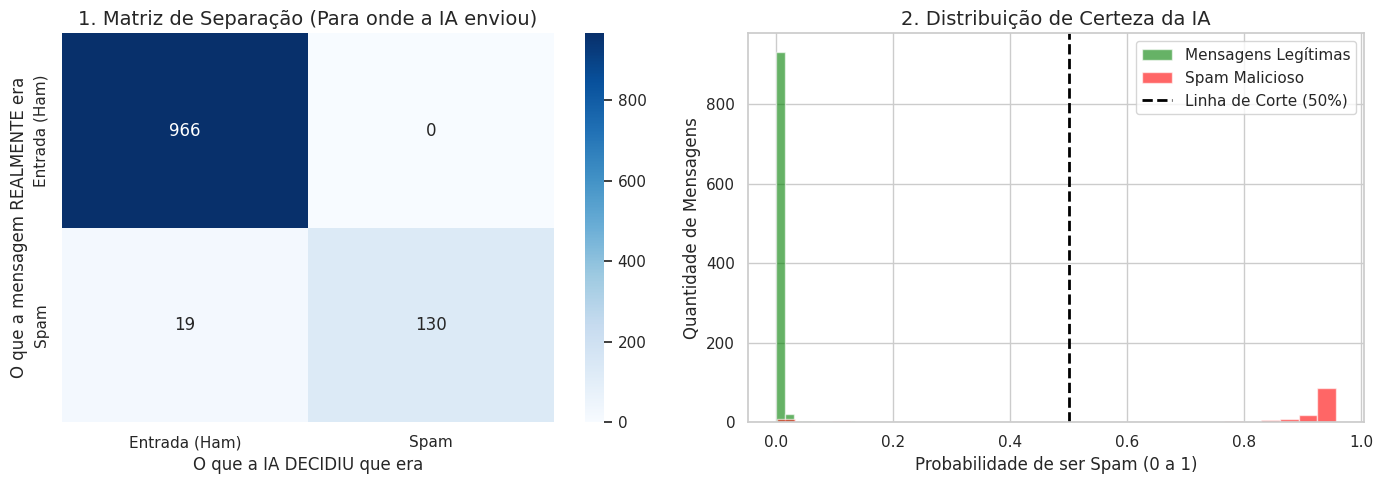

In [ ]:
# --- CÉLULA EXTRA: VISUALIZAÇÃO DA SEPARAÇÃO DA IA ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Gerando gráficos de separação...")

# 🛠️ A LINHA DA CORREÇÃO: Transformando os textos de teste em números para a IA entender
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Pega as predições da IA para o banco de dados de teste
predicoes = model.predict(X_test_seq, verbose=0)
predicoes_classes = (predicoes > 0.5).astype("int32")

# Configura o visual dos gráficos
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# GRÁFICO 1: Matriz de Confusão (Onde ela jogou cada mensagem)
cm = confusion_matrix(y_test, predicoes_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Entrada (Ham)', 'Spam'],
            yticklabels=['Entrada (Ham)', 'Spam'])
ax[0].set_title('1. Matriz de Separação (Para onde a IA enviou)', fontsize=14)
ax[0].set_ylabel('O que a mensagem REALMENTE era', fontsize=12)
ax[0].set_xlabel('O que a IA DECIDIU que era', fontsize=12)

# GRÁFICO 2: Distribuição de Probabilidades (O nível de certeza)
ax[1].hist(predicoes[y_test == 0], bins=30, color='green', alpha=0.6, label='Mensagens Legítimas')
ax[1].hist(predicoes[y_test == 1], bins=30, color='red', alpha=0.6, label='Spam Malicioso')
ax[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Linha de Corte (50%)')
ax[1].set_title('2. Distribuição de Certeza da IA', fontsize=14)
ax[1].set_xlabel('Probabilidade de ser Spam (0 a 1)', fontsize=12)
ax[1].set_ylabel('Quantidade de Mensagens', fontsize=12)
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 4. SIMULADOR E INTERFACE GRÁFICA
def simular_chegada_do_banco():
    idx = random.randint(0, len(X_test) - 1)
    texto_mensagem = X_test[idx]
    rotulo_real = y_test[idx]

    status_real_banco = "✉️ MENSAGEM VERDADEIRA (Ham)" if rotulo_real == 0 else "🚨 SPAM CONFIRMADO"

    sequencia = tokenizer.texts_to_sequences([texto_mensagem])
    vetor_pad = pad_sequences(sequencia, maxlen=max_len)
    probabilidade = model.predict(vetor_pad, verbose=0)[0][0]

    if probabilidade > 0.5:
        caixa_destino = "🚨 ENVIADO PARA A CAIXA DE SPAM"
        classificacao_ia = 1
    else:
        caixa_destino = "📥 ENVIADO PARA A CAIXA DE ENTRADA"
        classificacao_ia = 0

    if classificacao_ia == rotulo_real:
        resultado_auditoria = "🎯 A IA ACERTOU A SEPARAÇÃO!"
    else:
        resultado_auditoria = "❌ A IA ERROU DESTA VEZ!"

    porcentagem_certeza = f"{probabilidade * 100:.1f}%" if probabilidade > 0.5 else f"{(1 - probabilidade) * 100:.1f}%"

    return texto_mensagem, status_real_banco, caixa_destino, porcentagem_certeza, resultado_auditoria

with gr.Blocks(title="Simulador de Filtro LSTM") as demo:
    gr.Markdown("# 🛡️ Simulador de IA Anti-Spam")
    btn = gr.Button("🔄 Puxar Nova Mensagem do Banco de Dados", variant="primary")

    with gr.Row():
        txt_mensagem = gr.Textbox(label="Texto da Mensagem Recebida", lines=3, interactive=False)
    with gr.Row():
        txt_real = gr.Textbox(label="Rótulo Real Cadastrado no Banco", interactive=False)
        txt_ia = gr.Textbox(label="Decisão de Destino Tomada pela IA", interactive=False)
    with gr.Row():
        txt_certeza = gr.Textbox(label="Confiança da IA na Decisão", interactive=False)
        txt_resultado = gr.Textbox(label="Resultado da Auditoria", interactive=False)

    btn.click(fn=simular_chegada_do_banco, inputs=[], outputs=[txt_mensagem, txt_real, txt_ia, txt_certeza, txt_resultado])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79c2355a43a1042699.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
